In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

%matplotlib inline

In [3]:
datos = pd.read_csv(filepath_or_buffer = "/Users/paola/Desktop/SA1/beisbol.csv",sep=',',low_memory=False)

In [4]:
datos

,Unnamed: 0,equipos,bateos,runs
0,0,Texas,5659,855
1,1,Boston,5710,875
2,2,Detroit,5563,787
3,3,Kansas,5672,730
4,4,St.,5532,762
5,5,New_S.,5600,718
6,6,New_Y.,5518,867
7,7,Milwaukee,5447,721
8,8,Colorado,5544,735
9,9,Houston,5598,615


In [5]:
datos = datos.drop(columns=["Unnamed: 0"])

datos

,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762
5,New_S.,5600,718
6,New_Y.,5518,867
7,Milwaukee,5447,721
8,Colorado,5544,735
9,Houston,5598,615


In [6]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   equipos  30 non-null     str  
 1   bateos   30 non-null     int64
 2   runs     30 non-null     int64
dtypes: int64(2), str(1)
memory usage: 852.0 bytes


In [7]:
datos.describe()

,bateos,runs
count,30.000000,30.000000
mean,5523.500000,693.600000
std,79.873067,82.479088
min,5417.000000,556.000000
25%,5448.250000,629.000000
50%,5515.500000,705.500000
75%,5575.000000,734.000000
max,5710.000000,875.000000


In [8]:
datos.isnull().sum()

equipos    0
bateos     0
runs       0
dtype: int64

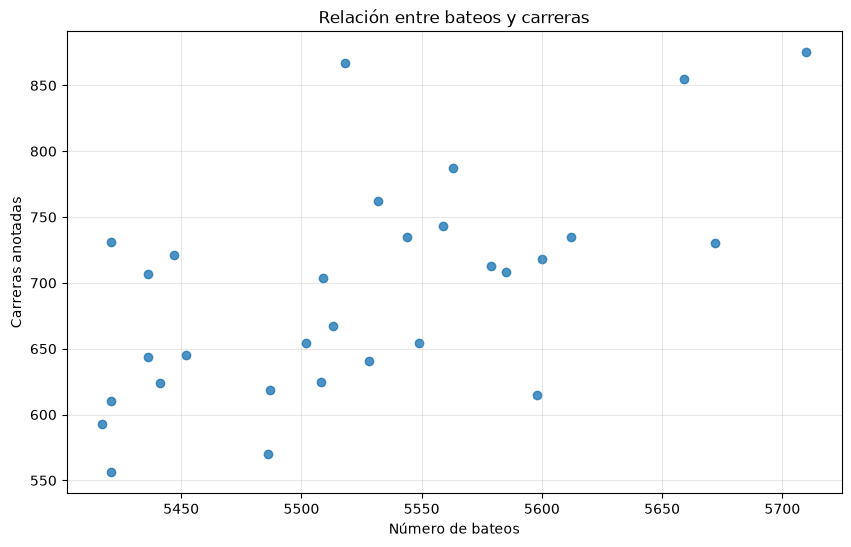

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(datos["bateos"], datos["runs"], alpha=0.8)

plt.title("Relación entre bateos y carreras")
plt.xlabel("Número de bateos")
plt.ylabel("Carreras anotadas")
plt.grid(alpha=0.3)

plt.show()

In [10]:
X = datos["bateos"].values.reshape(-1, 1)
y = datos["runs"].values.reshape(-1, 1)

In [11]:
X

array([[5659],
       [5710],
       [5563],
       [5672],
       [5532],
       [5600],
       [5518],
       [5447],
       [5544],
       [5598],
       [5585],
       [5436],
       [5549],
       [5612],
       [5513],
       [5579],
       [5502],
       [5509],
       [5421],
       [5559],
       [5487],
       [5508],
       [5421],
       [5452],
       [5436],
       [5528],
       [5441],
       [5486],
       [5417],
       [5421]])

In [12]:
y

array([[855],
       [875],
       [787],
       [730],
       [762],
       [718],
       [867],
       [721],
       [735],
       [615],
       [708],
       [644],
       [654],
       [735],
       [667],
       [713],
       [654],
       [704],
       [731],
       [743],
       [619],
       [625],
       [610],
       [645],
       [707],
       [641],
       [624],
       [570],
       [593],
       [556]])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

In [14]:
print("Datos de entrenamiento:", len(X_train))
print("Datos de prueba:", len(X_test))

Datos de entrenamiento: 24
Datos de prueba: 6


In [15]:
regressor = LinearRegression()

regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.64]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-2837.78]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[381.73]


In [16]:
print("Intercepto:", regressor.intercept_)
print("Coeficiente:", regressor.coef_)

Intercepto: [-2837.77687486]
Coeficiente: [[0.63897479]]


In [17]:
y_pred = regressor.predict(X_test)

y_pred

array([[716.83988729],
       [623.54956781],
       [748.14965205],
       [730.89733269],
       [638.88496279],
       [635.69008884]])

In [18]:
resultados = pd.DataFrame({
    "Real": y_test.flatten(),
    "Predicho": y_pred.flatten()
})

resultados

,Real,Predicho
0,787,716.839887
1,593,623.549568
2,735,748.149652
3,708,730.897333
4,624,638.884963
5,707,635.690089


In [19]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 37.158589869587935
MSE: 1976.597374864583
RMSE: 44.4589403254799
R²: 0.5399576825420558


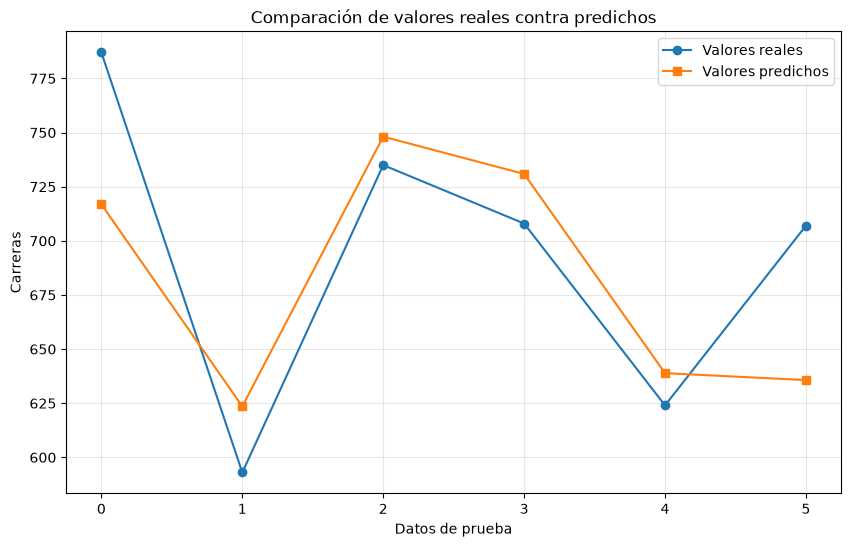

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(len(y_test)),
    y_test.flatten(),
    marker="o",
    label="Valores reales"
)

plt.plot(
    range(len(y_pred)),
    y_pred.flatten(),
    marker="s",
    label="Valores predichos"
)

plt.title("Comparación de valores reales contra predichos")
plt.xlabel("Datos de prueba")
plt.ylabel("Carreras")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

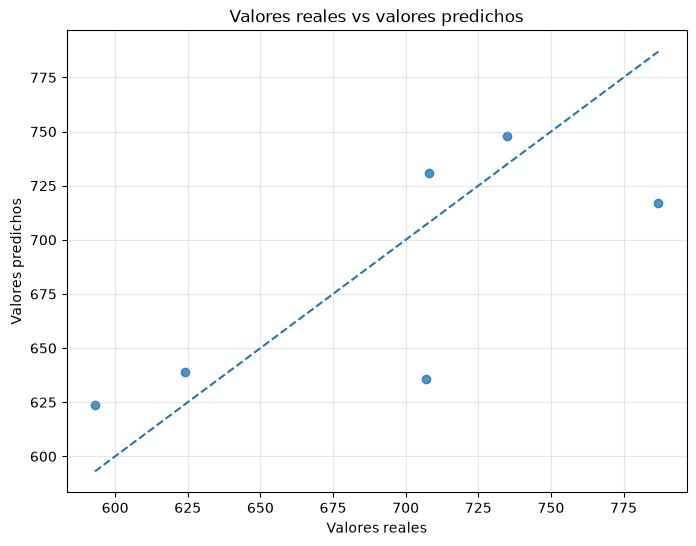

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.8)

min_valor = min(y_test.min(), y_pred.min())
max_valor = max(y_test.max(), y_pred.max())

plt.plot(
    [min_valor, max_valor],
    [min_valor, max_valor],
    linestyle="--"
)

plt.title("Valores reales vs valores predichos")
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.grid(alpha=0.3)

plt.show()

In [22]:
parametros = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

In [23]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=1
)

In [24]:
grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=parametros,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

In [25]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'fit_intercept': [True, False], 'positive': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedKFold...andom_state=1)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Co

In [26]:
print("Mejores parámetros:", grid.best_params_)
print("Mejor puntuación:", grid.best_score_)

Mejores parámetros: {'fit_intercept': True, 'positive': True}
Mejor puntuación: -5310.87390816853


In [27]:
modelo_optimizado = grid.best_estimator_

modelo_optimizado

,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.64]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-2837.78]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1


In [28]:
y_pred_optimizado = modelo_optimizado.predict(X_test)

In [29]:
mae_opt = metrics.mean_absolute_error(y_test, y_pred_optimizado)
mse_opt = metrics.mean_squared_error(y_test, y_pred_optimizado)
rmse_opt = np.sqrt(mse_opt)
r2_opt = metrics.r2_score(y_test, y_pred_optimizado)

print("MAE optimizado:", mae_opt)
print("MSE optimizado:", mse_opt)
print("RMSE optimizado:", rmse_opt)
print("R² optimizado:", r2_opt)

MAE optimizado: 37.158589869587935
MSE optimizado: 1976.597374864583
RMSE optimizado: 44.4589403254799
R² optimizado: 0.5399576825420558


In [30]:
comparacion = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Modelo original": [mae, mse, rmse, r2],
    "Modelo optimizado": [mae_opt, mse_opt, rmse_opt, r2_opt]
})

comparacion

,Métrica,Modelo original,Modelo optimizado
0,MAE,37.158590,37.158590
1,MSE,1976.597375,1976.597375
2,RMSE,44.458940,44.458940
3,R²,0.539958,0.539958


In [31]:
print("Mejores parámetros:", grid.best_params_)
print("Mejor puntuación:", grid.best_score_)

Mejores parámetros: {'fit_intercept': True, 'positive': True}
Mejor puntuación: -5310.87390816853


In [32]:
import joblib

joblib.dump(modelo_optimizado, "modelo_regresion_beisbol.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [33]:
resultados_finales = pd.DataFrame({
    "Valor real": y_test.flatten(),
    "Valor predicho": y_pred_optimizado.flatten(),
    "Error": y_test.flatten() - y_pred_optimizado.flatten()
})

resultados_finales

,Valor real,Valor predicho,Error
0,787,716.839887,70.160113
1,593,623.549568,-30.549568
2,735,748.149652,-13.149652
3,708,730.897333,-22.897333
4,624,638.884963,-14.884963
5,707,635.690089,71.309911


In [34]:
resultados_finales.to_csv(
    "resultados_regresion_beisbol.csv",
    index=False
)

In [35]:
modelo_cargado = joblib.load("modelo_regresion_beisbol.pkl")

predicciones_prueba = modelo_cargado.predict(X_test)

print(predicciones_prueba)

[[716.83988729]
 [623.54956781]
 [748.14965205]
 [730.89733269]
 [638.88496279]
 [635.69008884]]


In [36]:
import os

print(os.getcwd())

C:\Users\paola
